In [4]:
import pandas as pd 
import numpy as np 


IMPORT THE DATASET

In [5]:
loan = pd.read_excel(r"Downloads\loan_approval_dataset.xlsx")

In [6]:
loan

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


DROP THE LOAN_ID COLUMN

In [7]:
appr = loan.drop('loan_id', axis = 1)

In [10]:
appr.columns = appr.columns.str.strip()  #FOR THE MAKE ALL THE TEXT IN THE COLUMN IN LOWERCASE

ENCODING

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns = ['education', 'self_employed', 'loan_status']


for col in columns:
    appr[col] = le.fit_transform(appr[col])

In [12]:
appr

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0


TRAIN_TEST_SPLIT

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = appr.drop(['loan_status'], axis=1)
y = appr['loan_status']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

predicted = model.predict(X_test)

# print(predicted)

result = X_test.copy()
result['actual'] = y_test
result['predicted'] = predicted

print(result.head(10))

      no_of_dependents  education  self_employed  income_annum  loan_amount  \
1703                 5          0              0       5400000     19700000   
1173                 2          0              0       5900000     14000000   
308                  3          0              0       9600000     19900000   
1322                 2          0              0       6200000     23400000   
3271                 3          1              1       5800000     14100000   
3539                 4          0              1       4700000     12500000   
1522                 4          0              0       3400000     13500000   
3399                 5          1              1       5100000     13700000   
1402                 3          0              1       3300000      8500000   
1829                 1          1              1       3000000      6000000   

      loan_term  cibil_score  residential_assets_value  \
1703         20          423                   6500000   
1173          

METRICS

In [14]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

print("accuracy_score: ", (accuracy_score(y_test, predicted))*100)
print("precision_score: ", (precision_score(y_test, predicted))*100)
print("recall_score: ", (recall_score(y_test, predicted))*100)
print("F1_score: ", (f1_score(y_test, predicted))*100)


accuracy_score:  97.7751756440281
precision_score:  97.76357827476039
recall_score:  96.22641509433963
F1_score:  96.98890649762282


CONFUSION MATRIX

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted)
print(cm)

[[529   7]
 [ 12 306]]


CLASSIFICATION REPORT

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



CROSS VALIDATION

In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv= 5)
print((scores)*100)
print("average:", (scores.mean() * 100))

[98.24355972 97.65807963 98.36065574 97.89227166 98.35873388]
average: 98.10266012503052


In [18]:
#  model is not overfitting 

hyperparameter tunning

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Random Forest model
model = RandomForestClassifier(random_state=42)

# Hyperparameters to search
params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
random = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train with hyperparameter tuning
random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random.best_params_)

print("\nBest Cross Validation Score:")
print(random.best_score_)

# Best Model
best_model = random.best_estimator_

# Prediction
predicted = best_model.predict(X_test)

# Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test, predicted))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predicted))

Best Parameters:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Best Cross Validation Score:
0.9797950219619327

Test Accuracy:
0.9718969555035128

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.97      0.95      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [1]:
# COMAPARE THE HYPERPARAMETERED MODEL WITH PREVIOUS MODEL THEN NO BIG DIFFERENCE THAT SHOW SO CHOOSE THE SECOND MODEL THAT NAME IS THE "BEST_MODEL" 

IMPORTANT FEATURES

In [20]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                     Feature  Importance
6                cibil_score    0.840291
5                  loan_term    0.064314
4                loan_amount    0.023630
9        luxury_assets_value    0.013591
7   residential_assets_value    0.013391
8    commercial_assets_value    0.013153
3               income_annum    0.012083
10          bank_asset_value    0.011477
0           no_of_dependents    0.004975
2              self_employed    0.002205
1                  education    0.000890


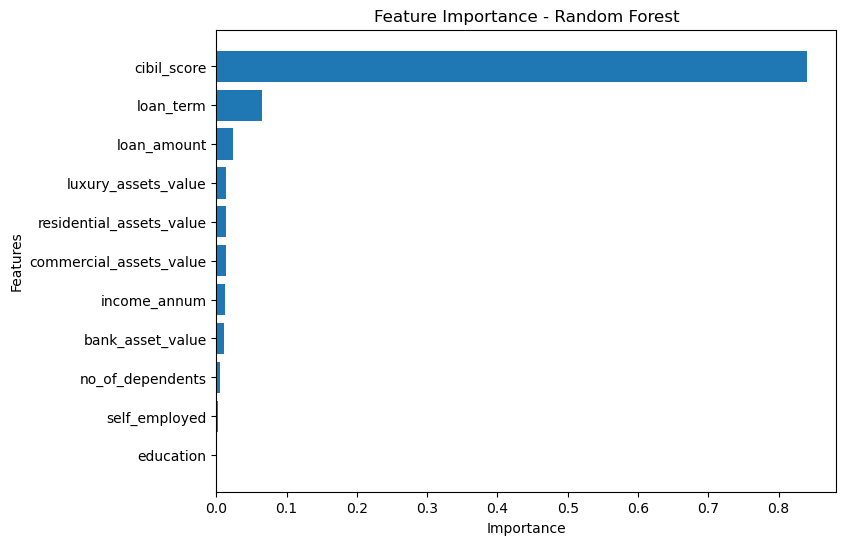

In [21]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.show()

CONFUSIOIN MATRIX HEATMAP OF THE "BEST MODEL"

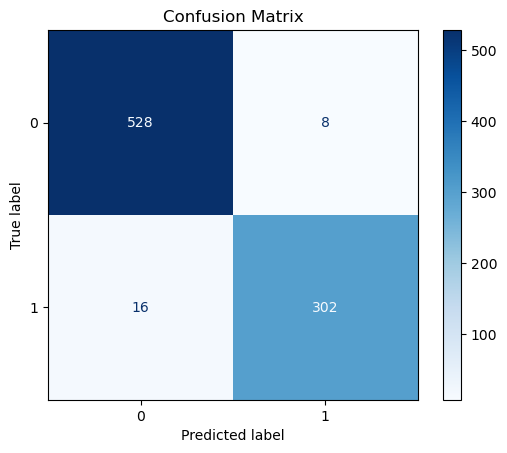

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [27]:
# TARGET CLASS DISTRIBUTION OF THE "best_model"

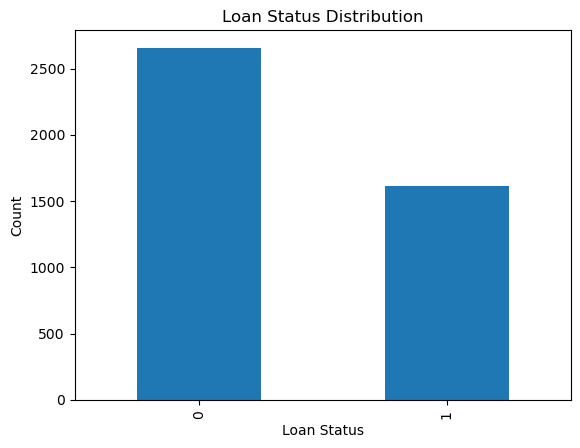

In [26]:
import matplotlib.pyplot as plt

appr['loan_status'].value_counts().plot(
    kind='bar'
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [ ]:
# CORRELATION HEATMAP OF THE "best_model"

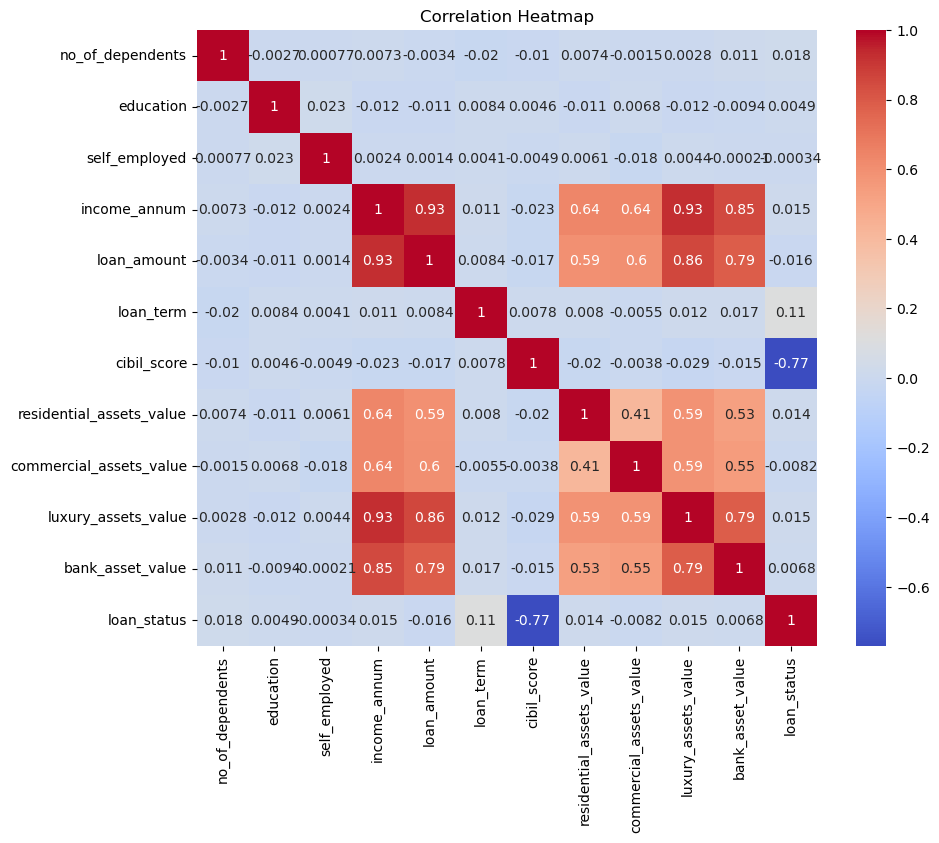

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    appr.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

FINAL MODEL

In [22]:
# -----------------------------
# User Input
# -----------------------------
cibil_score = int(input("Enter CIBIL Score (300 - 900): "))
loan_amount = int(input("Enter Loan Amount: "))
loan_term = int(input("Enter Loan Term: "))

income_annum = int(input("Enter Annual Income: "))
residential_assets_value = int(input("Enter Residential Assets Value: "))
commercial_assets_value = int(input("Enter Commercial Assets Value: "))
luxury_assets_value = int(input("Enter Luxury Assets Value: "))
bank_asset_value = int(input("Enter Bank Asset Value: "))

education = input("Education (Graduate/Not Graduate): ")
if education.strip().lower() == "Graduate":
    education = 1
else:
    education = 0

self_employed = input("Self Employed (Yes/No): ")
if self_employed.strip().lower() == "Yes":
    self_employed = 1
else:
    self_employed = 0

no_of_dependents = int(input("Enter Number of Dependents: "))


# -----------------------------
# Create Input Data
# -----------------------------
new_data = [[
    no_of_dependents,
    education,
    self_employed,
    income_annum,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets_value,
    commercial_assets_value,
    luxury_assets_value,
    bank_asset_value
]]

# -----------------------------
# Prediction
# -----------------------------
prediction = best_model.predict(new_data)

# -----------------------------
# Prediction Probability
# -----------------------------
probability = best_model.predict_proba(new_data)

# -----------------------------
# Display Result
# -----------------------------
print("\n========== RESULT ==========")

if prediction[0] == 1:
    print("Loan Status : APPROVED ✅")
else:
    print("Loan Status : REJECTED ❌")


print("\nPrediction Probability")
print("Rejected :", round(probability[0][0] * 100, 2), "%")
print("Approved :", round(probability[0][1] * 100, 2), "%")

Enter CIBIL Score (300 - 900):  450
Enter Loan Amount:  1200000
Enter Loan Term:  5
Enter Annual Income:  20000
Enter Residential Assets Value:  450000
Enter Commercial Assets Value:  2500000
Enter Luxury Assets Value:  450000
Enter Bank Asset Value:  860000
Education (Graduate/Not Graduate):  graduacate
Self Employed (Yes/No):  yes
Enter Number of Dependents:  2



========== RESULT ==========
Loan Status : REJECTED ❌

Prediction Probability
Rejected : 51.71 %
Approved : 48.29 %


C:\Users\Aryan Choudhari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Aryan Choudhari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
